### Install packages and create dataset from directory structure

In [1]:
!pip install tensorflow==2.16.1 keras==3.0.5


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import os
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "dataset_2D/training"
test_dir = "dataset_2D/testing"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2870 files belonging to 4 classes.
Found 394 files belonging to 4 classes.


In [3]:
class_names = train_dataset.class_names
print(class_names)
def convert_to_binary(images, labels):
    
    no_tumor_index = class_names.index('no_tumor')
    
    binary_labels = tf.where(labels == no_tumor_index, 0, 1)
    return images, binary_labels

train_dataset = train_dataset.map(convert_to_binary)
test_dataset = test_dataset.map(convert_to_binary)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [4]:
val_size = 0.2

train_batches = tf.data.experimental.cardinality(train_dataset).numpy()
val_batches = int(val_size * train_batches)

val_dataset = train_dataset.take(val_batches)
train_dataset = train_dataset.skip(val_batches)

### Tune the system, define and train the model 

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [6]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False 

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6729 - loss: 0.6283 - val_accuracy: 0.9149 - val_loss: 0.1971
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9162 - loss: 0.2202 - val_accuracy: 0.9444 - val_loss: 0.1435
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9544 - loss: 0.1393 - val_accuracy: 0.9670 - val_loss: 0.1002
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9679 - loss: 0.0914 - val_accuracy: 0.9740 - val_loss: 0.0812
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9757 - loss: 0.0815 - val_accuracy: 0.9757 - val_loss: 0.0657
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9779 - loss: 0.0650 - val_accuracy: 0.9809 - val_loss: 0.0586
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9803 - loss: 0.0617 - val_accuracy: 0.9844 - val_loss: 0.0538
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9854 - loss: 0.0475 - val_accuracy: 0.9844 - val_l

### Evaluate the model for different metrics

In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8898 - loss: 0.2917
Test Accuracy: 0.9391


In [10]:
model.save("MRI_ResNet.h5")

In [11]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    preds = model.predict(images)
    
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → binary predictions
y_pred = (y_pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["No Tumor", "Tumor"]))

Confusion Matrix:
 [[104   1]
 [ 23 266]]

Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.82      0.99      0.90       105
       Tumor       1.00      0.92      0.96       289

    accuracy                           0.94       394
   macro avg       0.91      0.96      0.93       394
weighted avg       0.95      0.94      0.94       394



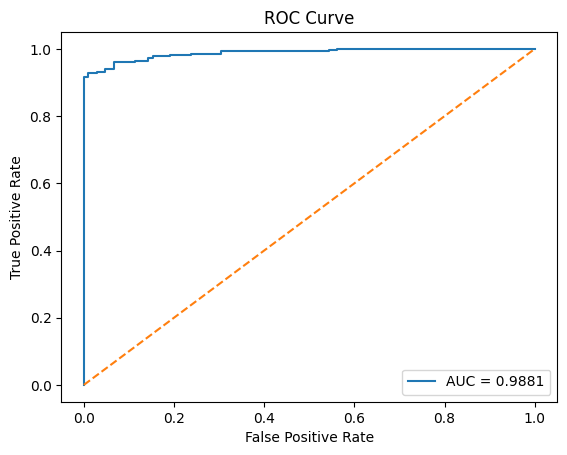

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

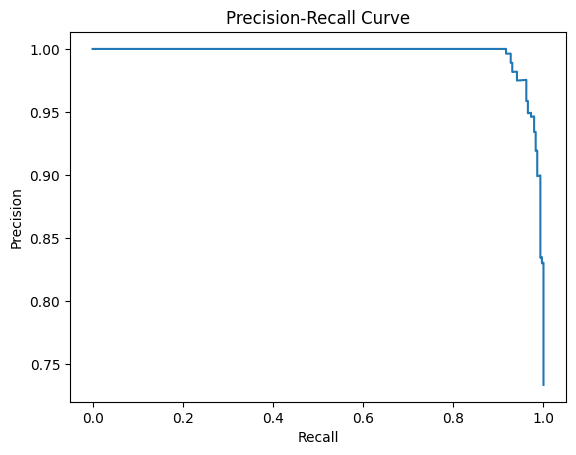

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

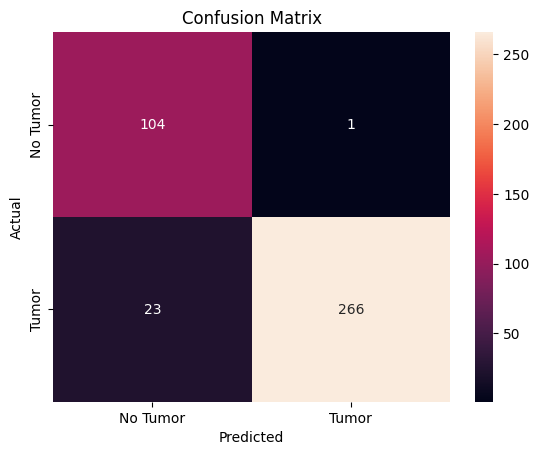

In [15]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Using Grad-CAM for model explanation 

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

LAST_CONV_LAYER = "conv5_block3_out"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

In [3]:
def overlay_heatmap(img, heatmap, alpha=0.5):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    img = img.astype(np.uint8)
    
    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    return overlay

In [4]:
def load_image(path, img_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    return img_array

img_path = "dataset_2D/testing/glioma_tumor/image(26).jpg"
img = load_image(img_path)

# Preprocess for ResNet
img_batch = np.expand_dims(img, axis=0)
img_batch = tf.keras.applications.resnet50.preprocess_input(img_batch)

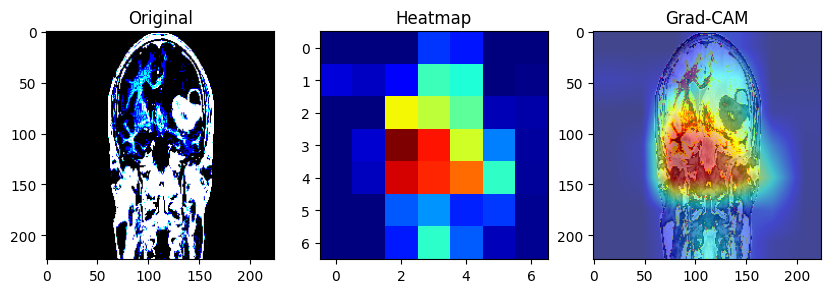

In [74]:
heatmap = make_gradcam_heatmap(img_batch, model, LAST_CONV_LAYER)

overlay = overlay_heatmap(img, heatmap)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Heatmap")
plt.imshow(heatmap, cmap='jet')

plt.subplot(1,3,3)
plt.title("Grad-CAM")
plt.imshow(overlay)

plt.show()

### Use more XAI methods like Integrated Gradients, SmoothGrad and Grad-CAM++ and visualize the explanations

In [5]:
import numpy as np
def integrated_gradients(model, img, steps=50):
    
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    baseline = tf.zeros_like(img)
    
    # Generate interpolated images
    alphas = tf.linspace(0.0, 1.0, steps+1)
    alphas = tf.reshape(alphas, (-1, 1, 1, 1))
    
    interpolated = baseline + alphas * (img - baseline)
    
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
        loss = preds[:, 0]
    
    grads = tape.gradient(loss, interpolated)
    
    # Average gradients
    avg_grads = tf.reduce_mean(grads, axis=0)
    
    integrated_grads = (img - baseline)[0] * avg_grads
    
    heatmap = tf.reduce_sum(tf.abs(integrated_grads), axis=-1)
    
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

In [6]:
def smoothgrad(model, img, num_samples=20, noise_level=0.1):
    
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    
    grads_list = []
    
    for _ in range(num_samples):
        noise = tf.random.normal(shape=tf.shape(img), stddev=noise_level)
        noisy_img = img + noise
        
        with tf.GradientTape() as tape:
            tape.watch(noisy_img)
            preds = model(noisy_img)
            loss = preds[:, 0]
        
        grads = tape.gradient(loss, noisy_img)
        grads_list.append(grads)
    
    avg_grads = tf.reduce_mean(tf.stack(grads_list), axis=0)
    
    heatmap = tf.reduce_mean(tf.abs(avg_grads[0]), axis=-1)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

In [7]:
def gradcam_plus_plus(img_array, model, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]]
    )
    
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    
    # First, second, third derivatives
    first = grads
    second = grads ** 2
    third = grads ** 3
    
    global_sum = tf.reduce_sum(conv_outputs, axis=(1,2))
    
    alpha_num = second
    alpha_denom = 2 * second + third * global_sum[:, None, None, :]
    alpha_denom = tf.where(alpha_denom != 0, alpha_denom, tf.ones_like(alpha_denom))
    
    alphas = alpha_num / alpha_denom
    
    weights = tf.reduce_sum(alphas * tf.nn.relu(first), axis=(1,2))
    
    cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)
    
    heatmap = tf.maximum(cam[0], 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy()

In [41]:
img = load_image(img_path)
img_batch = np.expand_dims(img, axis=0)
img_batch = tf.keras.applications.resnet50.preprocess_input(img_batch)

In [76]:
gradcam_map = make_gradcam_heatmap(img_batch, model, LAST_CONV_LAYER)
gcampp_map = gradcam_plus_plus(img_batch, model, LAST_CONV_LAYER)
ig_map = integrated_gradients(model, img_batch)
smooth_map = smoothgrad(model, img_batch)

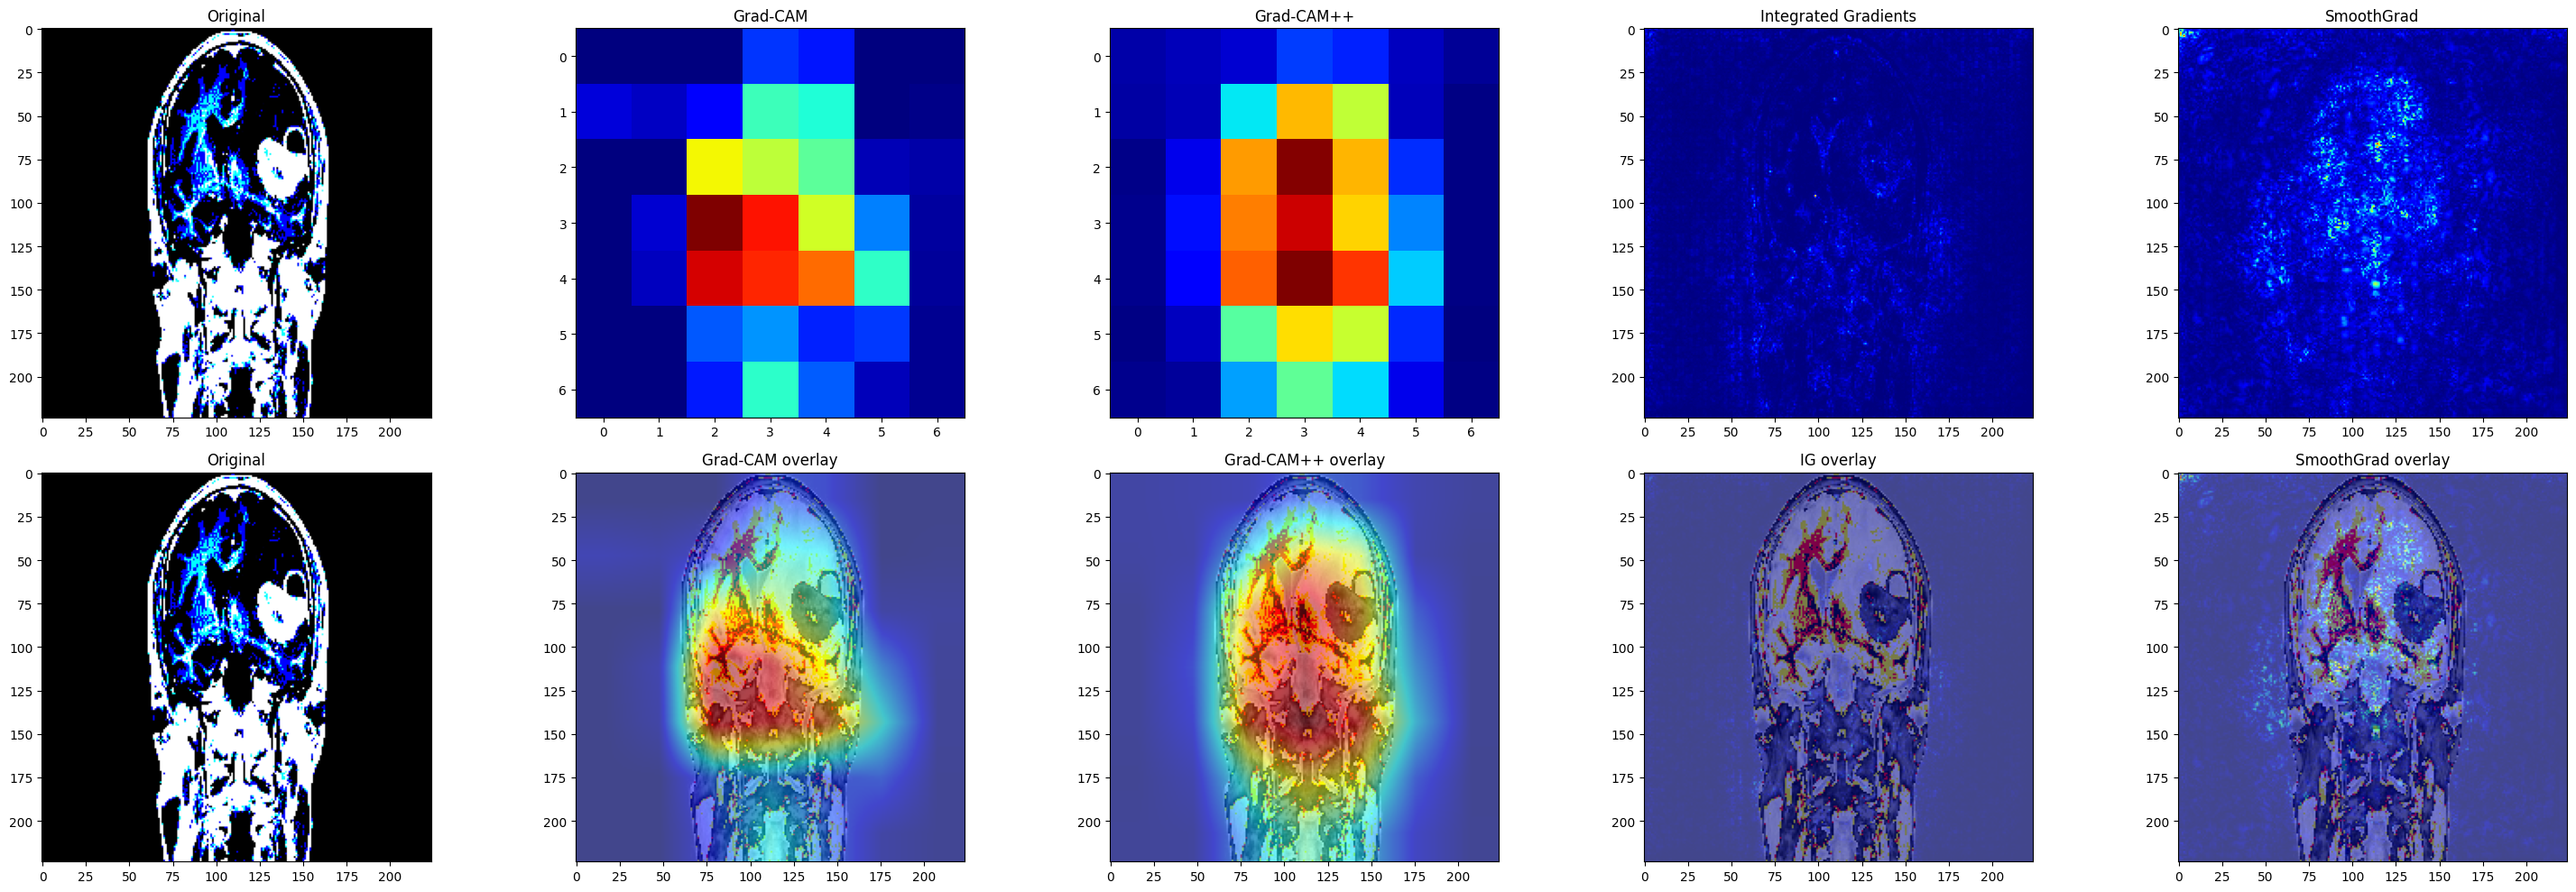

In [77]:
plt.figure(figsize=(30,10))

# Row 1: raw maps
plt.subplot(2,5,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(2,5,2)
plt.title("Grad-CAM")
plt.imshow(gradcam_map, cmap='jet')

plt.subplot(2,5,3)
plt.title("Grad-CAM++")
plt.imshow(gcampp_map, cmap='jet')

plt.subplot(2,5,4)
plt.title("Integrated Gradients")
plt.imshow(ig_map, cmap='jet')

plt.subplot(2,5,5)
plt.title("SmoothGrad")
plt.imshow(smooth_map, cmap='jet')


# Row 2: overlays
plt.subplot(2,5,6)
plt.title("Original")
plt.imshow(img)

plt.subplot(2,5,7)
plt.title("Grad-CAM overlay")
plt.imshow(overlay_heatmap(img, gradcam_map))

plt.subplot(2,5,8)
plt.title("Grad-CAM++ overlay")
plt.imshow(overlay_heatmap(img, gcampp_map))

plt.subplot(2,5,9)
plt.title("IG overlay")
plt.imshow(overlay_heatmap(img, ig_map))

plt.subplot(2,5,10)
plt.title("SmoothGrad overlay")
plt.imshow(overlay_heatmap(img, smooth_map))

plt.tight_layout()
plt.show()

### Compare the impact of choosen layer for XAI

In [68]:
LAYER_DEEP = "conv5_block3_out"
LAYER_SHALLOW = "conv4_block6_out"

heatmap_deep = make_gradcam_heatmap(img_batch, model, LAYER_DEEP)
heatmap_shallow = make_gradcam_heatmap(img_batch, model, LAYER_SHALLOW)

In [69]:
heatmap_deep_resized = cv2.resize(heatmap_deep, (img.shape[1], img.shape[0]))
heatmap_shallow_resized = cv2.resize(heatmap_shallow, (img.shape[1], img.shape[0]))

In [70]:
def smooth(hm):
    return cv2.GaussianBlur(hm, (11,11), 0)

heatmap_deep_resized = smooth(heatmap_deep_resized)
heatmap_shallow_resized = smooth(heatmap_shallow_resized)

In [78]:
overlay_deep = overlay_heatmap(img, heatmap_deep_resized)
overlay_shallow = overlay_heatmap(img, heatmap_shallow_resized)

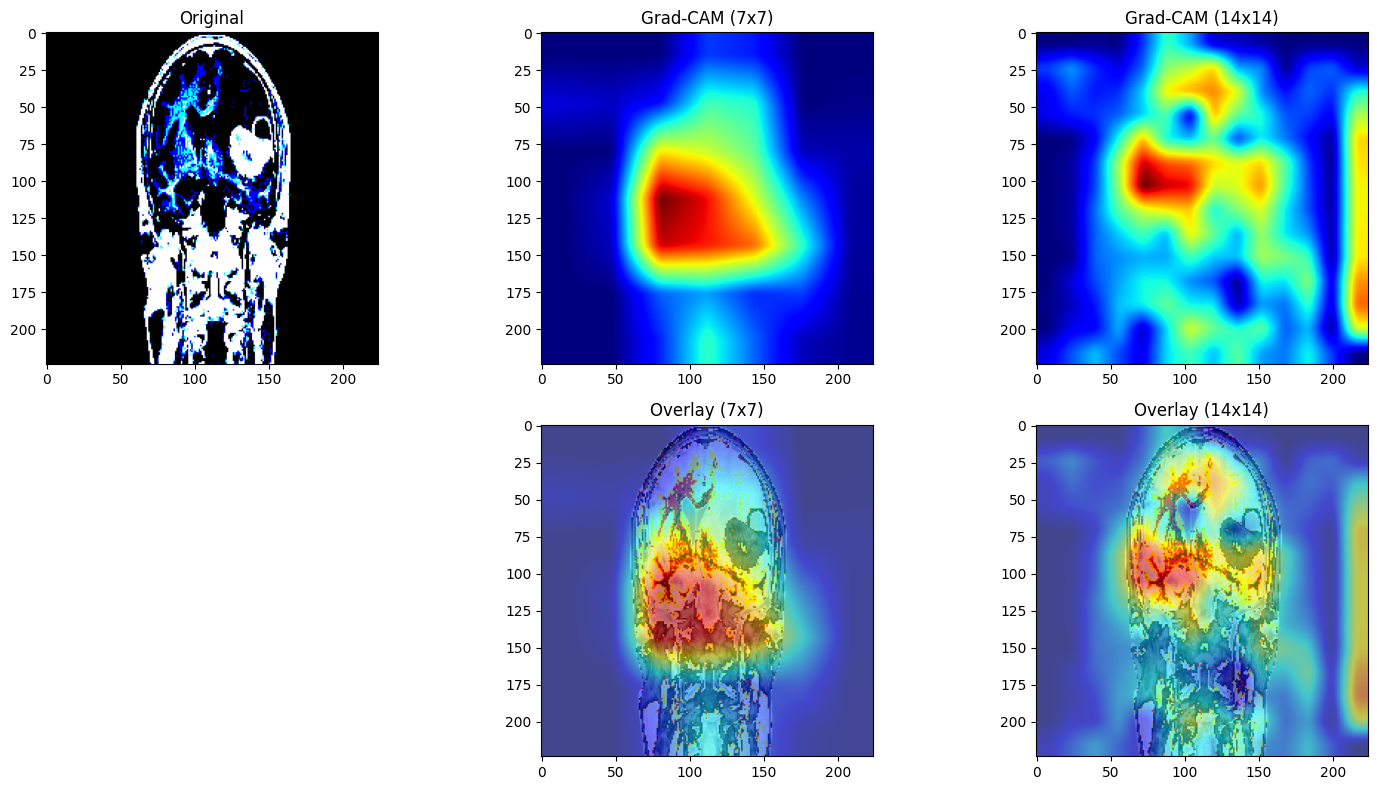

In [79]:
plt.figure(figsize=(15,8))

# Raw maps
plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(2,3,2)
plt.title("Grad-CAM (7x7)")
plt.imshow(heatmap_deep_resized, cmap='jet')

plt.subplot(2,3,3)
plt.title("Grad-CAM (14x14)")
plt.imshow(heatmap_shallow_resized, cmap='jet')

# Overlays
plt.subplot(2,3,5)
plt.title("Overlay (7x7)")
plt.imshow(overlay_deep)

plt.subplot(2,3,6)
plt.title("Overlay (14x14)")
plt.imshow(overlay_shallow)

plt.tight_layout()
plt.show()

### Quantitative evaluation (IoU, DICE) for all the XAI methods

In [1]:
import tensorflow as tf

model = tf.keras.models.load_model("MRI_ResNet.h5", compile=False)

In [8]:
import nibabel as nib
import numpy as np
import os
import cv2

def get_central_slice(patient_path):
    
    flair_path = [f for f in os.listdir(patient_path) if "flair" in f][0]
    seg_path   = [f for f in os.listdir(patient_path) if "seg" in f][0]
    
    flair = nib.load(os.path.join(patient_path, flair_path)).get_fdata()
    mask  = nib.load(os.path.join(patient_path, seg_path)).get_fdata()
    
    tumor_slices = [i for i in range(mask.shape[2]) if np.sum(mask[:,:,i]) > 0]
    
    mid = tumor_slices[len(tumor_slices)//2]
    
    img = flair[:,:,mid]
    gt  = (mask[:,:,mid] > 0).astype(np.uint8)
    
    # normalize
    img = (img - np.min(img)) / (np.max(img) - np.min(img))
    img = (img * 255).astype(np.uint8)
    
    img = cv2.resize(img, (224,224))
    gt  = cv2.resize(gt, (224,224), interpolation=cv2.INTER_NEAREST)
    
    # convert to 3-channel
    img_3 = np.stack([img]*3, axis=-1)
    
    return img_3, gt

In [15]:
root_dir = "BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData"

patients = sorted(os.listdir(root_dir))[:3]

data = [get_central_slice(os.path.join(root_dir, p)) for p in patients]

In [16]:
def dice_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-8)

def iou_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum((y_true + y_pred) > 0)
    return intersection / (union + 1e-8)

In [17]:
def heatmap_to_mask(heatmap, thresh=0.4):
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return (heatmap > thresh).astype(np.uint8)

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output[0]]  
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [33]:
all_results = []

for i, (img, gt) in enumerate(data):
    
    img_batch = np.expand_dims(img, axis=0)
    img_batch = tf.keras.applications.resnet50.preprocess_input(img_batch)
    
    gradcam = make_gradcam_heatmap(img_batch, model, "conv5_block3_out")
    gcampp  = gradcam_plus_plus(img_batch, model, "conv5_block3_out")
    ig      = integrated_gradients(model, img_batch)
    smooth  = smoothgrad(model, img_batch)
    
    all_results.append({
        "img": img,
        "gt": gt,
        "gradcam": gradcam,
        "gcampp": gcampp,
        "ig": ig,
        "smooth": smooth
    })

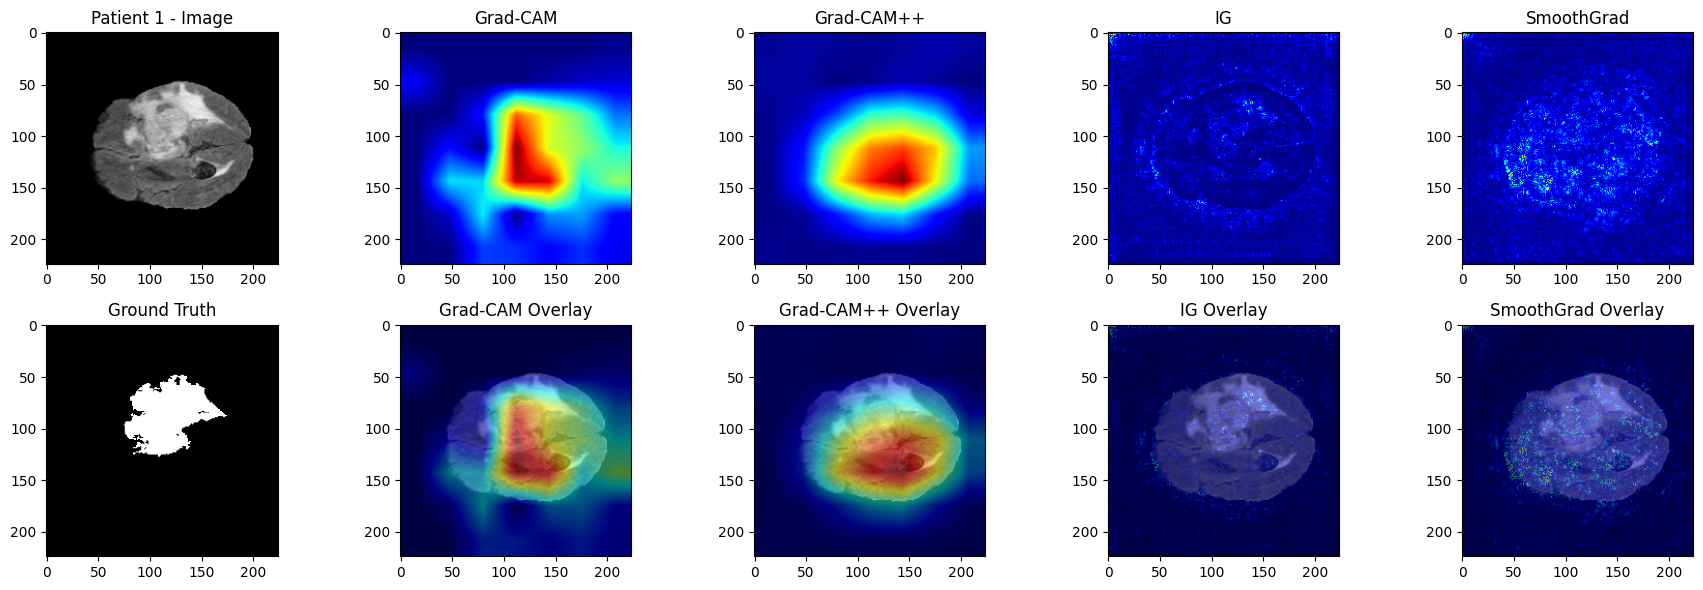

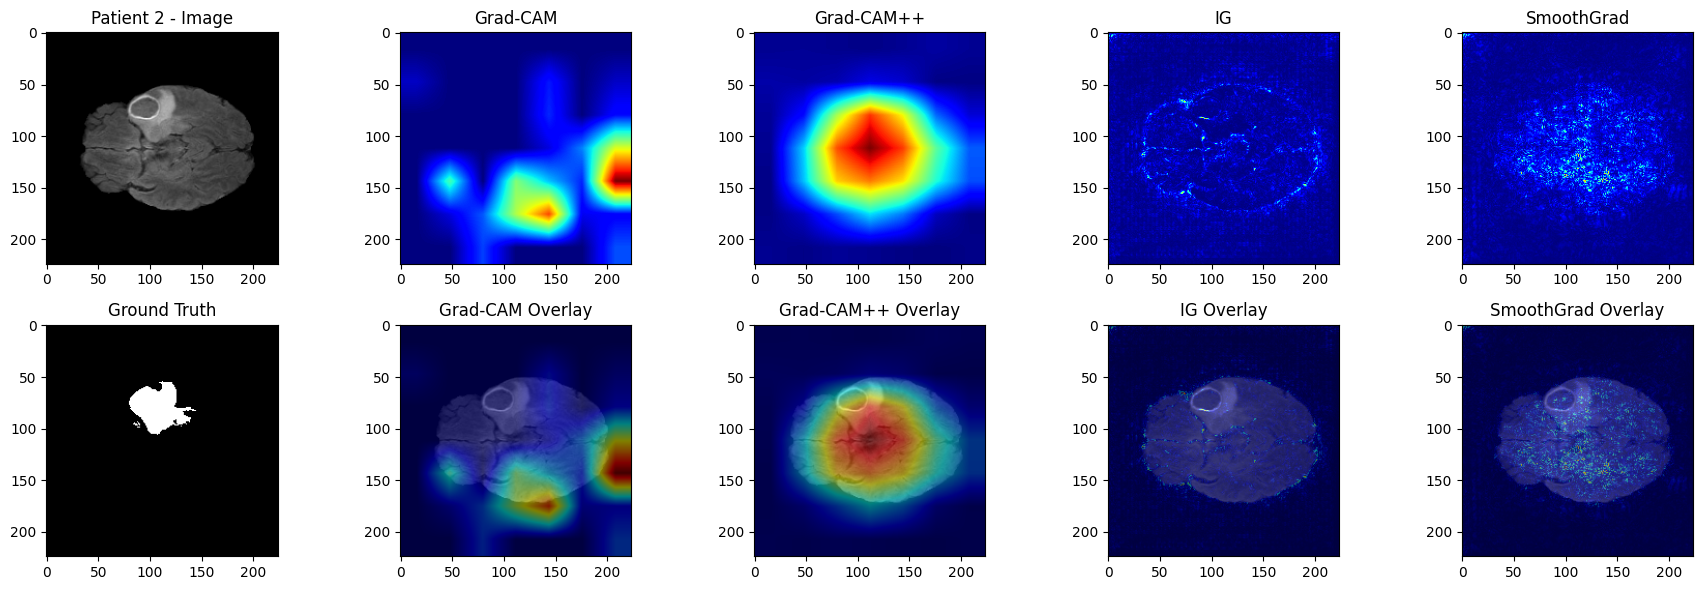

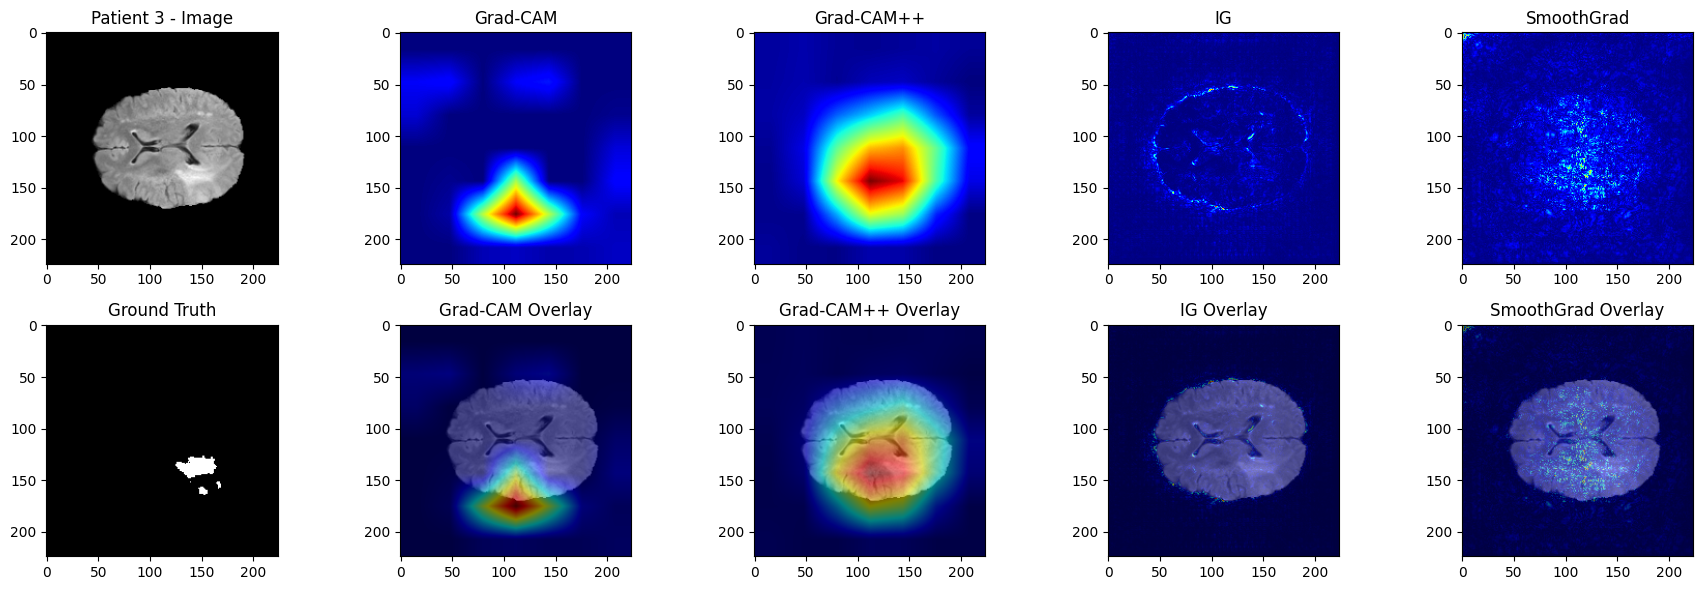

In [34]:
import matplotlib.pyplot as plt

for i, res in enumerate(all_results):
    
    img = res["img"]
    gt = res["gt"]
    
    gradcam = res["gradcam"]
    gcampp = res["gcampp"]
    ig = res["ig"]
    smooth = res["smooth"]
    
    plt.figure(figsize=(18,6))
    
    # Row 1: heatmaps
    plt.subplot(2,5,1)
    plt.title(f"Patient {i+1} - Image")
    plt.imshow(img.astype("uint8"))
    
    plt.subplot(2,5,2)
    plt.title("Grad-CAM")
    plt.imshow(cv2.resize(gradcam, (224,224)), cmap='jet')
    
    plt.subplot(2,5,3)
    plt.title("Grad-CAM++")
    plt.imshow(cv2.resize(gcampp, (224,224)), cmap='jet')
    
    plt.subplot(2,5,4)
    plt.title("IG")
    plt.imshow(cv2.resize(ig, (224,224)), cmap='jet')
    
    plt.subplot(2,5,5)
    plt.title("SmoothGrad")
    plt.imshow(cv2.resize(smooth, (224,224)), cmap='jet')
    
    
    # Row 2: overlays
    plt.subplot(2,5,6)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap='gray')
    
    plt.subplot(2,5,7)
    plt.title("Grad-CAM Overlay")
    plt.imshow(overlay_heatmap(img, gradcam))
    
    plt.subplot(2,5,8)
    plt.title("Grad-CAM++ Overlay")
    plt.imshow(overlay_heatmap(img, gcampp))
    
    plt.subplot(2,5,9)
    plt.title("IG Overlay")
    plt.imshow(overlay_heatmap(img, ig))
    
    plt.subplot(2,5,10)
    plt.title("SmoothGrad Overlay")
    plt.imshow(overlay_heatmap(img, smooth))
    
    plt.tight_layout()
    plt.show()

In [35]:
import pandas as pd

def heatmap_to_mask(heatmap, thresh=0.4):
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = heatmap - np.min(heatmap)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return (heatmap > thresh).astype(np.uint8)

def dice_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-8)

def iou_score(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum((y_true + y_pred) > 0)
    return intersection / (union + 1e-8)

In [36]:
records = []

for i, res in enumerate(all_results):
    
    gt = res["gt"]
    
    methods = {
        "GradCAM": res["gradcam"],
        "GradCAM++": res["gcampp"],
        "IG": res["ig"],
        "SmoothGrad": res["smooth"]
    }
    
    for name, hm in methods.items():
        
        pred_mask = heatmap_to_mask(hm, thresh=0.4)
        
        dice = dice_score(gt, pred_mask)
        iou = iou_score(gt, pred_mask)
        
        records.append({
            "Patient": i+1,
            "Method": name,
            "Dice": dice,
            "IoU": iou
        })

In [37]:
df = pd.DataFrame(records)
print(df)

    Patient      Method      Dice       IoU
0         1     GradCAM  0.427787  0.272092
1         1   GradCAM++  0.357441  0.217613
2         1          IG  0.003218  0.001612
3         1  SmoothGrad  0.007501  0.003764
4         2     GradCAM  0.000000  0.000000
5         2   GradCAM++  0.263571  0.151789
6         2          IG  0.006448  0.003235
7         2  SmoothGrad  0.023529  0.011905
8         3     GradCAM  0.000000  0.000000
9         3   GradCAM++  0.122774  0.065402
10        3          IG  0.000000  0.000000
11        3  SmoothGrad  0.021557  0.010896


In [38]:
avg_df = df.groupby("Method")[["Dice","IoU"]].mean()
print("\nAverage Performance:\n")
print(avg_df)


Average Performance:

                Dice       IoU
Method                        
GradCAM     0.142596  0.090697
GradCAM++   0.247929  0.144934
IG          0.003222  0.001615
SmoothGrad  0.017529  0.008855


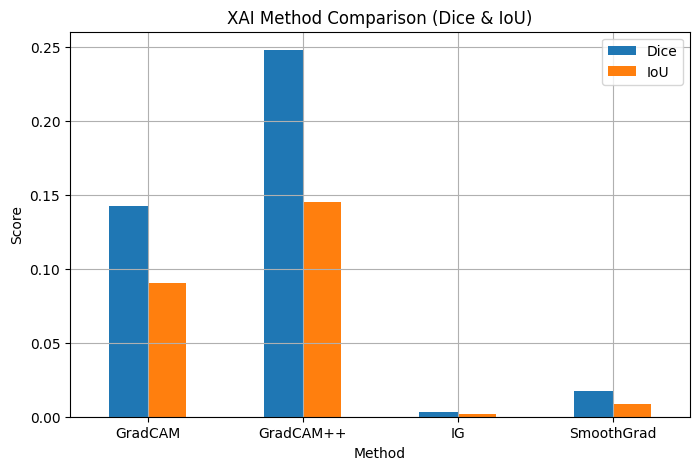

In [39]:
import matplotlib.pyplot as plt

avg_df.plot(kind="bar", figsize=(8,5))
plt.title("XAI Method Comparison (Dice & IoU)")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.grid()
plt.show()

### Faithfulness test (Deletion and Insertion AUC) using pixel blackout for all XAI methods

In [40]:
def get_score(model, img):
    img_batch = np.expand_dims(img, axis=0)
    img_batch = tf.keras.applications.resnet50.preprocess_input(img_batch)
    return model.predict(img_batch, verbose=0)[0][0]

In [41]:
def prepare_heatmap(heatmap):
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = heatmap - np.min(heatmap)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return heatmap

In [42]:
def deletion_curve(model, img, heatmap, steps=20):
    
    heatmap = prepare_heatmap(heatmap)
    
    img_copy = img.copy()
    h, w, _ = img.shape
    
    scores = []
    
    # Flatten indices sorted by importance (high → low)
    indices = np.argsort(-heatmap.flatten())
    
    total_pixels = h * w
    step_size = total_pixels // steps
    
    for i in range(steps):
        
        # remove top-k important pixels
        idx = indices[: (i+1)*step_size]
        
        img_temp = img_copy.copy().reshape(-1,3)
        img_temp[idx] = 0   # black out
        
        img_temp = img_temp.reshape(h,w,3)
        
        score = get_score(model, img_temp)
        scores.append(score)
    
    return scores

In [43]:
def insertion_curve(model, img, heatmap, steps=20):
    
    heatmap = prepare_heatmap(heatmap)
    
    h, w, _ = img.shape
    
    # start from blurred image
    img_blur = cv2.GaussianBlur(img, (51,51), 0)
    
    img_temp = img_blur.copy().reshape(-1,3)
    original = img.reshape(-1,3)
    
    scores = []
    
    indices = np.argsort(-heatmap.flatten())
    step_size = (h*w)//steps
    
    for i in range(steps):
        
        idx = indices[: (i+1)*step_size]
        
        img_temp[idx] = original[idx]
        
        current_img = img_temp.reshape(h,w,3)
        
        score = get_score(model, current_img)
        scores.append(score)
    
    return scores

In [44]:
res = all_results[0]  # first patient

img = res["img"]

methods = {
    "GradCAM": res["gradcam"],
    "GradCAM++": res["gcampp"],
    "IG": res["ig"],
    "SmoothGrad": res["smooth"]
}

deletion_results = {}
insertion_results = {}

for name, hm in methods.items():
    deletion_results[name] = deletion_curve(model, img, hm)
    insertion_results[name] = insertion_curve(model, img, hm)

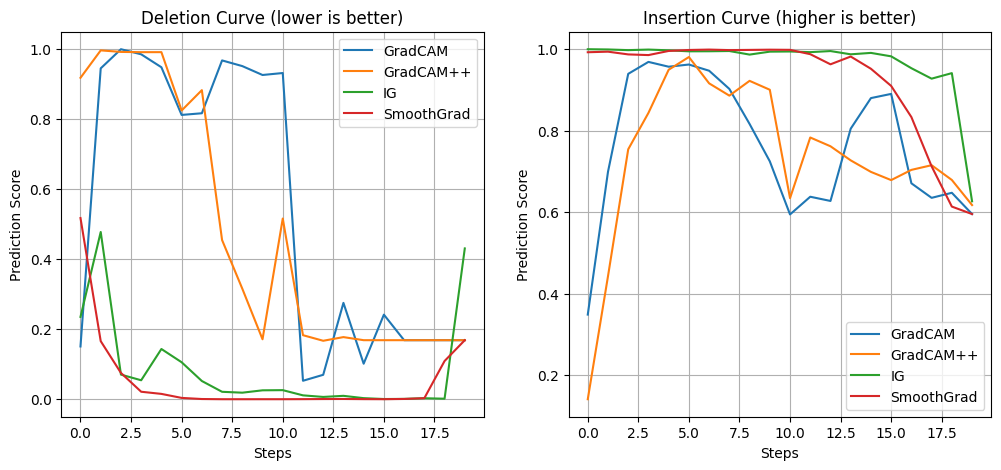

In [45]:
plt.figure(figsize=(12,5))

# Deletion
plt.subplot(1,2,1)
for name, scores in deletion_results.items():
    plt.plot(scores, label=name)
plt.title("Deletion Curve (lower is better)")
plt.xlabel("Steps")
plt.ylabel("Prediction Score")
plt.legend()
plt.grid()

# Insertion
plt.subplot(1,2,2)
for name, scores in insertion_results.items():
    plt.plot(scores, label=name)
plt.title("Insertion Curve (higher is better)")
plt.xlabel("Steps")
plt.ylabel("Prediction Score")
plt.legend()
plt.grid()

plt.show()

In [48]:
def compute_auc(scores):
    scores = np.array(scores)
    x = np.linspace(0, 1, len(scores))  # normalize x-axis
    auc = np.trapz(scores, x)
    return auc

auc_results = []

for name in methods.keys():
    
    del_auc = compute_auc(deletion_results[name])
    ins_auc = compute_auc(insertion_results[name])
    
    auc_results.append({
        "Method": name,
        "Deletion_AUC": del_auc,
        "Insertion_AUC": ins_auc
    })

import pandas as pd
df_auc = pd.DataFrame(auc_results)
print(df_auc)

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.561803       0.777816
1   GradCAM++      0.475610       0.755679
2          IG      0.071700       0.975611
3  SmoothGrad      0.038914       0.931560


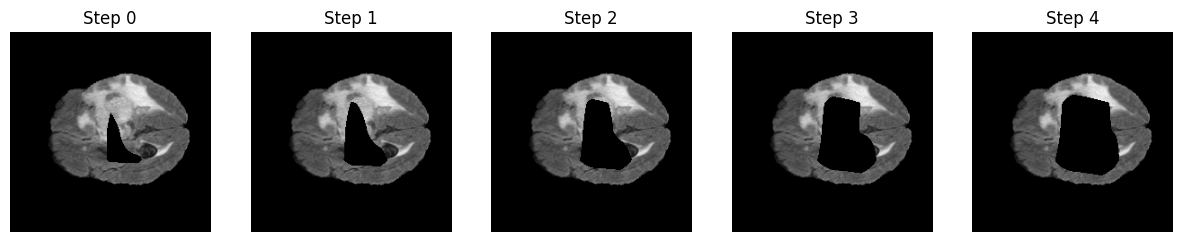

In [47]:
plt.figure(figsize=(15,3))

for i in range(5):
    idx = np.argsort(-prepare_heatmap(res["gradcam"]).flatten())[:(i+1)*1000]
    
    temp = img.copy().reshape(-1,3)
    temp[idx] = 0
    temp = temp.reshape(224,224,3)
    
    plt.subplot(1,5,i+1)
    plt.imshow(temp)
    plt.title(f"Step {i}")
    plt.axis('off')

plt.show()

### Faitfulness test (Deletion and Insertion AUC) using three methods (Pixel blackout, Pixel blur, Region blur) to reduce bias towards methods

In [49]:
def normalize_heatmap(hm):
    hm = hm - np.min(hm)
    hm = hm / (np.max(hm) + 1e-8)
    return hm

def compute_auc(scores):
    scores = np.array(scores)
    x = np.linspace(0, 1, len(scores))
    return np.trapz(scores, x)

In [50]:
def deletion_pixel_black(model, img, heatmap, steps=20):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w, _ = img.shape
    indices = np.argsort(-heatmap.flatten())
    step_size = (h*w)//steps
    
    img_temp = img.copy().reshape(-1,3)
    scores = []
    
    for i in range(steps):
        idx = indices[:(i+1)*step_size]
        img_temp[idx] = 0
        
        current = img_temp.reshape(h,w,3)
        scores.append(get_score(model, current))
    
    return scores

In [51]:
def insertion_pixel_black(model, img, heatmap, steps=20):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w, _ = img.shape
    indices = np.argsort(-heatmap.flatten())
    step_size = (h*w)//steps
    
    img_temp = np.zeros_like(img).reshape(-1,3)
    original = img.reshape(-1,3)
    
    scores = []
    
    for i in range(steps):
        idx = indices[:(i+1)*step_size]
        img_temp[idx] = original[idx]
        
        current = img_temp.reshape(h,w,3)
        scores.append(get_score(model, current))
    
    return scores

In [52]:
def deletion_pixel_blur(model, img, heatmap, steps=20):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w, _ = img.shape
    blur = cv2.GaussianBlur(img, (51,51), 0)
    
    indices = np.argsort(-heatmap.flatten())
    step_size = (h*w)//steps
    
    img_temp = img.copy().reshape(-1,3)
    blur_flat = blur.reshape(-1,3)
    
    scores = []
    
    for i in range(steps):
        idx = indices[:(i+1)*step_size]
        img_temp[idx] = blur_flat[idx]
        
        current = img_temp.reshape(h,w,3)
        scores.append(get_score(model, current))
    
    return scores

In [53]:
def insertion_pixel_blur(model, img, heatmap, steps=20):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w, _ = img.shape
    blur = cv2.GaussianBlur(img, (51,51), 0)
    
    indices = np.argsort(-heatmap.flatten())
    step_size = (h*w)//steps
    
    img_temp = blur.copy().reshape(-1,3)
    original = img.reshape(-1,3)
    
    scores = []
    
    for i in range(steps):
        idx = indices[:(i+1)*step_size]
        img_temp[idx] = original[idx]
        
        current = img_temp.reshape(h,w,3)
        scores.append(get_score(model, current))
    
    return scores

In [54]:
def deletion_region_blur(model, img, heatmap, steps=20, patch=8):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w = heatmap.shape
    blur = cv2.GaussianBlur(img, (51,51), 0)
    
    # Compute patch importance
    patches = []
    for i in range(0, h, patch):
        for j in range(0, w, patch):
            score = np.mean(heatmap[i:i+patch, j:j+patch])
            patches.append((score, i, j))
    
    patches.sort(reverse=True)
    step_size = len(patches)//steps
    
    img_temp = img.copy()
    scores = []
    
    for i in range(steps):
        for k in range((i+1)*step_size):
            _, x, y = patches[k]
            img_temp[x:x+patch, y:y+patch] = blur[x:x+patch, y:y+patch]
        
        scores.append(get_score(model, img_temp))
    
    return scores

In [55]:
def insertion_region_blur(model, img, heatmap, steps=20, patch=8):
    
    heatmap = normalize_heatmap(cv2.resize(heatmap, (224,224)))
    
    h, w = heatmap.shape
    blur = cv2.GaussianBlur(img, (51,51), 0)
    
    patches = []
    for i in range(0, h, patch):
        for j in range(0, w, patch):
            score = np.mean(heatmap[i:i+patch, j:j+patch])
            patches.append((score, i, j))
    
    patches.sort(reverse=True)
    step_size = len(patches)//steps
    
    img_temp = blur.copy()
    scores = []
    
    for i in range(steps):
        for k in range((i+1)*step_size):
            _, x, y = patches[k]
            img_temp[x:x+patch, y:y+patch] = img[x:x+patch, y:y+patch]
        
        scores.append(get_score(model, img_temp))
    
    return scores

In [56]:
res = all_results[0]
img = res["img"]

methods = {
    "GradCAM": res["gradcam"],
    "GradCAM++": res["gcampp"],
    "IG": res["ig"],
    "SmoothGrad": res["smooth"]
}

In [57]:
import pandas as pd

def evaluate_setting(del_fn, ins_fn, name):
    
    records = []
    
    for m, hm in methods.items():
        
        del_scores = del_fn(model, img, hm)
        ins_scores = ins_fn(model, img, hm)
        
        records.append({
            "Method": m,
            "Deletion_AUC": compute_auc(del_scores),
            "Insertion_AUC": compute_auc(ins_scores)
        })
    
    df = pd.DataFrame(records)
    print(f"\n{name} Results:\n")
    print(df)
    
    return df

In [58]:
df_black = evaluate_setting(deletion_pixel_black, insertion_pixel_black, "Pixel Blackout")

df_blur = evaluate_setting(deletion_pixel_blur, insertion_pixel_blur, "Pixel Blur")

df_region = evaluate_setting(deletion_region_blur, insertion_region_blur, "Region Blur")


Pixel Blackout Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.561803       0.510033
1   GradCAM++      0.475610       0.486641
2          IG      0.071700       0.116402
3  SmoothGrad      0.038914       0.229747

Pixel Blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.358333       0.777816
1   GradCAM++      0.668713       0.755679
2          IG      0.968915       0.975611
3  SmoothGrad      0.909227       0.931560

Region Blur Results:

       Method  Deletion_AUC  Insertion_AUC
0     GradCAM      0.451570       0.797011
1   GradCAM++      0.538463       0.741839
2          IG      0.659973       0.580319
3  SmoothGrad      0.129770       0.634976


In [59]:
def plot_curves(del_fn, ins_fn, title):
    
    plt.figure(figsize=(12,5))
    
    # Deletion
    plt.subplot(1,2,1)
    for m, hm in methods.items():
        scores = del_fn(model, img, hm)
        plt.plot(scores, label=m)
    plt.title(f"{title} - Deletion")
    plt.legend(); plt.grid()
    
    # Insertion
    plt.subplot(1,2,2)
    for m, hm in methods.items():
        scores = ins_fn(model, img, hm)
        plt.plot(scores, label=m)
    plt.title(f"{title} - Insertion")
    plt.legend(); plt.grid()
    
    plt.show()

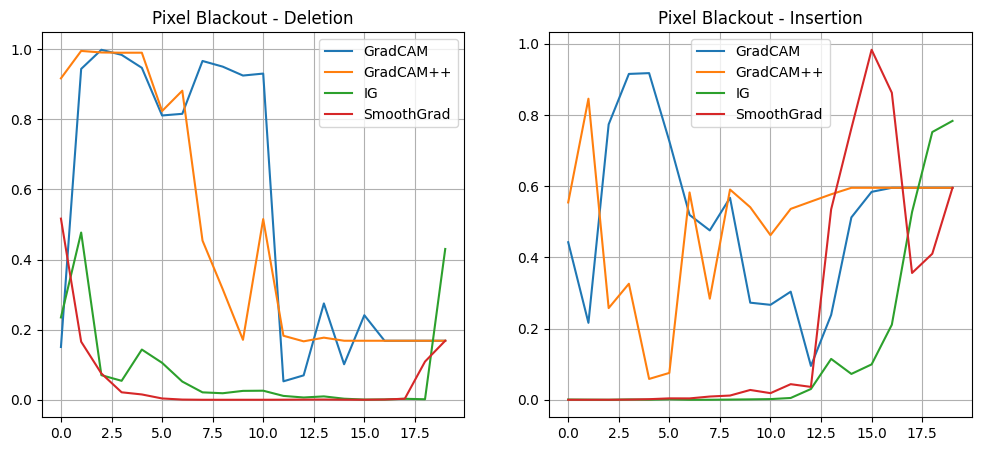

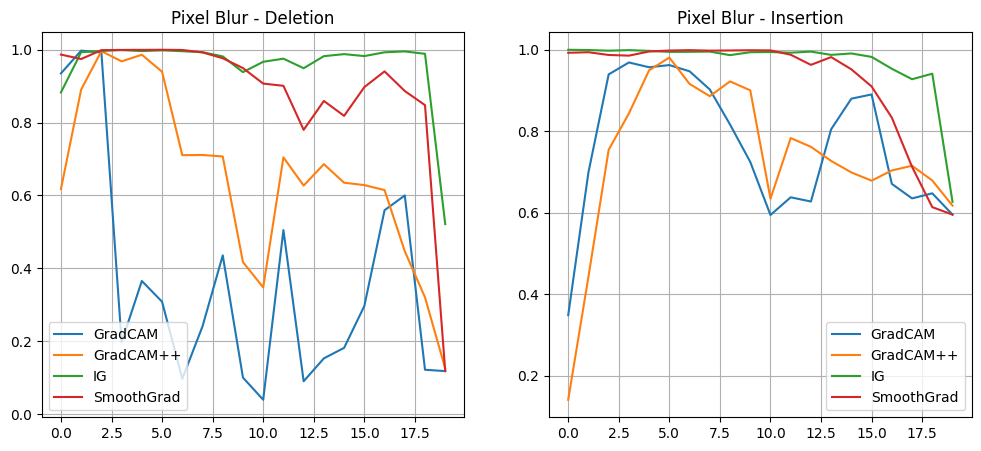

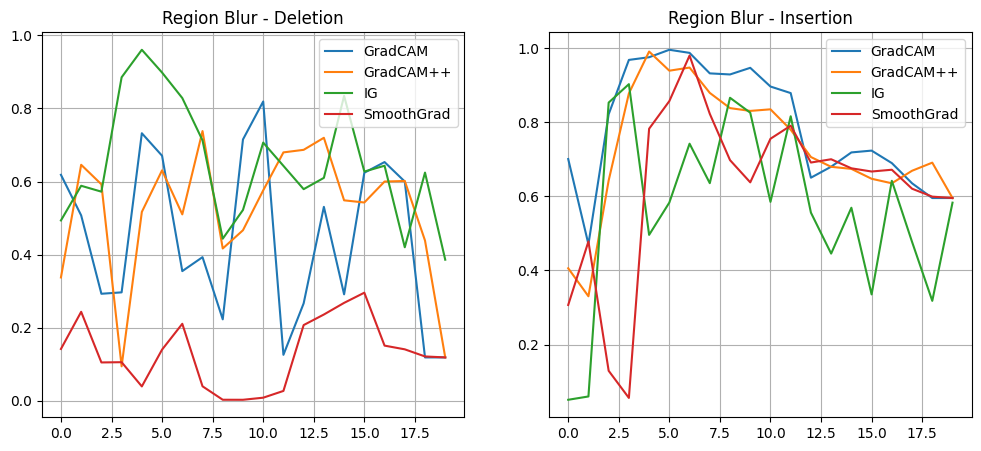

In [60]:
plot_curves(deletion_pixel_black, insertion_pixel_black, "Pixel Blackout")
plot_curves(deletion_pixel_blur, insertion_pixel_blur, "Pixel Blur")
plot_curves(deletion_region_blur, insertion_region_blur, "Region Blur")

### Final faithfulness comparison across XAI methods

In [61]:
final_df = pd.concat([
    df_black.assign(Setting="Pixel Blackout"),
    df_blur.assign(Setting="Pixel Blur"),
    df_region.assign(Setting="Region Blur")
])

print(final_df)

       Method  Deletion_AUC  Insertion_AUC         Setting
0     GradCAM      0.561803       0.510033  Pixel Blackout
1   GradCAM++      0.475610       0.486641  Pixel Blackout
2          IG      0.071700       0.116402  Pixel Blackout
3  SmoothGrad      0.038914       0.229747  Pixel Blackout
0     GradCAM      0.358333       0.777816      Pixel Blur
1   GradCAM++      0.668713       0.755679      Pixel Blur
2          IG      0.968915       0.975611      Pixel Blur
3  SmoothGrad      0.909227       0.931560      Pixel Blur
0     GradCAM      0.451570       0.797011     Region Blur
1   GradCAM++      0.538463       0.741839     Region Blur
2          IG      0.659973       0.580319     Region Blur
3  SmoothGrad      0.129770       0.634976     Region Blur


In [62]:
pivot = final_df.pivot(index="Method", columns="Setting")
print(pivot)

             Deletion_AUC                         Insertion_AUC             \
Setting    Pixel Blackout Pixel Blur Region Blur Pixel Blackout Pixel Blur   
Method                                                                       
GradCAM          0.561803   0.358333    0.451570       0.510033   0.777816   
GradCAM++        0.475610   0.668713    0.538463       0.486641   0.755679   
IG               0.071700   0.968915    0.659973       0.116402   0.975611   
SmoothGrad       0.038914   0.909227    0.129770       0.229747   0.931560   

                        
Setting    Region Blur  
Method                  
GradCAM       0.797011  
GradCAM++     0.741839  
IG            0.580319  
SmoothGrad    0.634976  


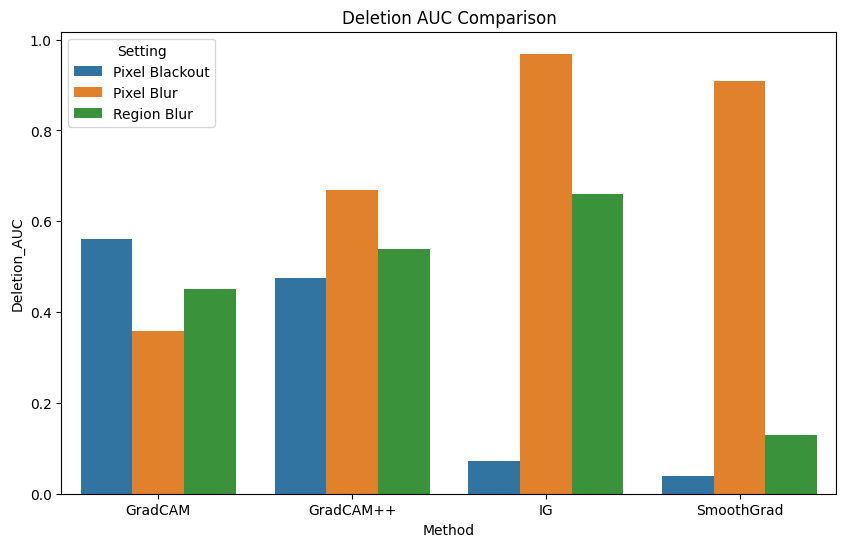

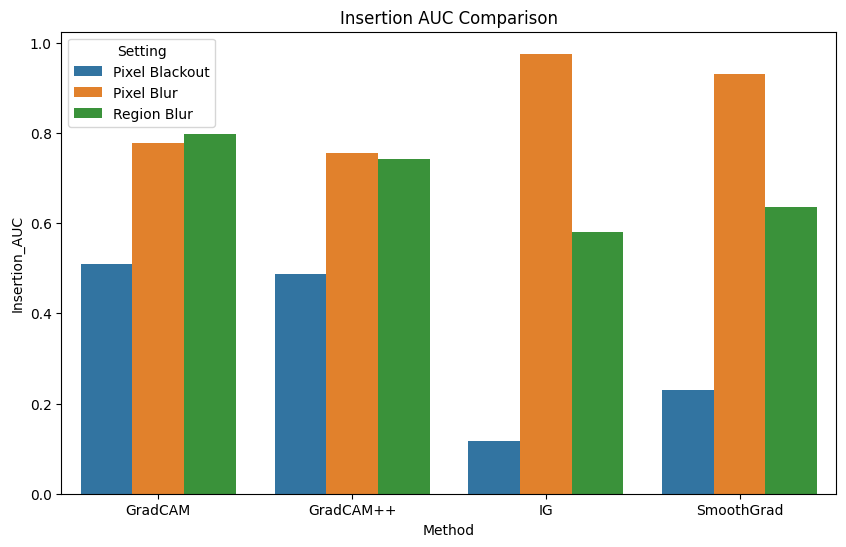

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Deletion_AUC", hue="Setting")
plt.title("Deletion AUC Comparison")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=final_df, x="Method", y="Insertion_AUC", hue="Setting")
plt.title("Insertion AUC Comparison")
plt.show()